# Saltillo Operational Disruption: Scenario Analysis and Revenue Impact.  

*A Simulation Based on Saltillo, Coahuila, Mexico (2010).*

---

## 1. Executive Summary.

This analysis quantifies the financial impact of a major operational disruption in fuel stations in Saltillo, where road closures reduced customer accessibility and directly affected revenue generation.

Using a scenario-based modeling approach, two representative station profiles were analyzed:
- **Store A (High Exposure):** Direct dependence on the disrupted roadway.  
- **Store B (Moderate Exposure):** Partial accessibility through alternative routes.  

Under full closure conditions, stations with high exposure experience severe revenue losses, with Store A showing an average weekly decline of approximately **MXN 435,000 (~USD 25,600), equivalent to an ~84% reduction**. Even stations with partial alternative access (Store B) sustain significant losses of approximately **MXN 329,000 (~USD 19,350) per week**.

However, results show that **accessibility operates as a continuous driver of revenue, not a binary condition**. During partial reopening (single-lane access), Store B significantly improves performance, reducing losses to approximately **~27%**, demonstrating that even limited access materially stabilizes demand.

This reframes operational disruption as a **manageable financial variable,** where incremental improvements in accessibility translate into measurable revenue recovery.

From a decision-making perspective, this enables organizations to:

- Quantify revenue at risk under different disruption scenarios.  
- Evaluate the financial return of partial reopening strategies.  
- Prioritize operational actions that accelerate access restoration.  

Overall, accessibility emerges not only as a logistical constraint, but as a **core lever for revenue protection and operational resilience**.

From an operational standpoint, this supports **prioritizing partial reopening strategies as a high-impact, low-cost intervention** to mitigate revenue losses during disruption periods.

## 2. Business Context.

In 2010, a series of boulevard construction works in Saltillo, Mexico disrupted direct access to multiple fuel stations, immediately impacting customer traffic and weekly revenue.

At the onset of the construction, all affected stations experienced a full loss of direct access. Entry points were effectively blocked, leading to a sharp and simultaneous decline in throughput across locations.

Given the strong dependency of fuel station performance on traffic flow and ease of access, this restriction translated directly into reduced customer visits and revenue contraction.

In response, the Gas Stations Legal Team negotiated with local authorities to partially restore access. This resulted in the reopening of a single operational lane, allowing controlled but limited vehicle entry to the stations.

While this partial reopening improved accessibility, it did not restore normal operating conditions. Traffic flow remained constrained, limiting customer volume and preventing full revenue recovery.

This situation can be understood as a sequence of three operational phases:

- **Full Closure**: No direct access; severe disruption in customer inflow and revenue.
- **Partial Reopening (Single-Lane Access)**: Limited vehicle entry through one lane; partial recovery with constrained throughput.
- **Normal Access**: Full restoration of traffic flow and operational conditions.

Operational teams implemented mitigation measures during the disruption, including traffic coordination, visibility improvements, and targeted promotions. These actions helped stabilize performance but were not sufficient to offset the structural limitation imposed by restricted access.

This context raises three core business questions:

- How much revenue is exposed under full accessibility loss?
- To what extent can single-lane access mitigate financial impact?
- What level of recovery can be expected once full access is restored?

These questions directly inform infrastructure negotiation strategies, contingency planning, and prioritization of operational responses.

This project addresses these questions by quantifying revenue exposure and recovery across the three defined accessibility conditions.

## 3. Analytical Objective.

This analysis quantifies how road accessibility constraints impact fuel station revenue during disruption scenarios, using weekly performance as the primary measure.

The focus is on four elements:

- Revenue sensitivity to different accessibility levels (full closure, partial reopening, full access).  
- Weekly revenue loss under constrained conditions.  
- Differences in recovery behavior across high- and moderate-exposure locations.  
- The extent to which partial access reduces financial impact.  

From a decision perspective, the analysis addresses three questions:

1. How much revenue is at risk when access is restricted?  
2. Is partial access sufficient to sustain acceptable performance levels?  
3. How quickly does revenue recover once full accessibility is restored?  

These outputs support operational planning, financial impact assessment, and prioritization of mitigation and recovery actions.

Weekly revenue is used as the core KPI across all scenarios to isolate the direct impact of accessibility constraints.

## 4. Approach.

This section details the full technical implementation of the modeling framework used to analyze the impact of road accessibility disruptions on weekly fuel sales.

The approach combines:
- Synthetic dataset generation reflecting real operational dynamics.
- Machine Learning forecasting using LightGBM.
- Structural time-series modeling using Prophet.

Each component is designed to capture different aspects of demand behavior:
- LightGBM captures nonlinear patterns and short-term dynamics.
- Prophet provides interpretable structural decomposition.

The analysis is organized into sequential steps covering data preparation, model training, scenario simulation, and interpretation.

### 4.1 Introduction.

The modeling strategy is designed to simulate the financial and operational impact of a one-time disruption event under different accessibility conditions.

The dataset incorporates:
- Weekly sales observations.
- Accessibility regimes (full closure, partial reopening, normal access).
- Temporal features (seasonality, lags, rolling averages).

Two complementary modeling approaches are applied:

**1. LightGBM:**
- Learns nonlinear demand patterns.
- Captures short-term dynamics and autoregressive effects.
- Enables recursive scenario simulation.

**2. Prophet:**
- Decomposes demand into structural components (trend + seasonality).
- Incorporates accessibility as exogenous regressors.
- Provides interpretable long-term recovery dynamics.

The objective is not only to forecast sales but to evaluate how different operational recovery strategies influence revenue trajectories.

**Note: (USD equivalents are approximate and based on an exchange rate of 1 USD ≈ 17 MXN.)**

### Scenario Design Note: Partial Reopening Duration.

The synthetic dataset models a disruption period where partial reopening occurs over a limited duration (`partial_weeks = 20`), reflecting observed operational recovery patterns within the historical simulation.

However, in the scenario analysis sections, a longer partial reopening window (`partial_weeks = 30`) is intentionally applied.

This distinction serves two purposes:

- The dataset captures **realistic short-term recovery behavior** under disruption conditions.
- The scenario models extend the partial reopening phase to evaluate **forward-looking intervention strategies**, allowing for a more comprehensive assessment of how sustained limited access impacts revenue recovery.

By separating these two time horizons, the analysis distinguishes between:
- **Observed system behavior** (data generation), and  
- **Decision-oriented scenario testing** (simulation)

This enables a more flexible evaluation of operational strategies without being constrained by the exact duration observed in the synthetic dataset.



### 4.2 Synthetic Dataset Design and Feature Engineering.

To simulate the operational and financial dynamics observed during the 2010 Saltillo disruption, a synthetic weekly fuel sales dataset was constructed over a multi-year time horizon (170 weeks).

This dataset is intentionally designed to replicate real-world business conditions while ensuring full control over scenario design and modeling inputs.

The dataset represents three distinct store behaviors:

- **Store A:** Severe disruption (full closure) with delayed recovery due to lack of early intervention.  
- **Store B:** Moderate disruption with partial recovery enabled by a one-lane reopening.  
- **Store C:** Unaffected control store, serving as a baseline benchmark.  

Each observation corresponds to a weekly record and includes both structural and engineered features required for forecasting models.


#### a) Core Variables.

- **Date:** Weekly timestamp formatted for time-series modeling.  
- **Week_Num:** Week-of-year index (1–53), enabling cyclical pattern recognition.  
- **Sales:** Simulated weekly revenue (in thousands of USD).  
- **Store:** Store identifier (A, B, C).  


#### b) Operational Regime Variables.

- **road_closure:** Binary indicator of disruption (1 = closure, 0 = normal).  
- **intervention:** Binary indicator of managerial action (1 = intervention applied).  
- **access_level:** Continuous accessibility metric capturing operational capacity:
  - 1.0 → Full access  
  - 0.5 → Partial reopening (one-lane access)  
  - 0.0 → Full closure  

These variables are critical for modeling **structural demand elasticity** under different accessibility conditions.


#### c) Engineered Features.

To improve forecasting performance and capture temporal dependencies:

- **Lag_1, Lag_2, Lag_3:** Previous 1–3 weeks of sales (short-term memory effects).  
- **MA_3:** Rolling 3-week average (local smoothing).  
- **sin_week, cos_week:** Seasonal encodings to model annual cyclicality.  

These features enable both:
- **Machine Learning models (LightGBM)** → capturing nonlinear patterns and autoregressive behavior.  
- **Statistical models (Prophet)** → incorporating exogenous regressors into structural decomposition.  


#### d) Modeling Rationale.

This dataset structure allows the analysis to:

- Compare **degrees of disruption across stores.**
- Quantify **revenue loss and recovery trajectories.**
- Evaluate **impact of managerial intervention.**
- Simulate **counterfactual recovery scenarios.**
- Support both **predictive (ML)** and **structural (time-series)** modeling approaches.  

The dataset is fully generated within the notebook, ensuring:
- No dependency on external data sources.  
- Full reproducibility.  
- Controlled experimentation across scenarios.  

In [1]:
# ==========================================================
# Synthetic Dataset – Saltillo Structural Disruption
# ==========================================================

import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------------
# GLOBAL PARAMETERS
# -----------------------------
weeks = 170
shock_week = 120
partial_weeks = 20

stores = ["A", "B", "C"]
data = []

for store in stores:

    # -----------------------------
    # STORE-SPECIFIC SETTINGS
    # -----------------------------
    if store == "A":   # High impact
        base = 520
        closure_drop = 0.90   # catastrophic
        partial_drop = 0.60

    elif store == "B": # Moderate impact
        base = 500
        closure_drop = 0.70
        partial_drop = 0.40

    else:              # Store C – TRUE CONTROL
        base = 510
        closure_drop = 0.0
        partial_drop = 0.0

    for week in range(1, weeks + 1):

        # -----------------------------
        # ACCESS REGIME
        # -----------------------------
        if store == "C":
            access = 1.0
        else:
            if week < shock_week:
                access = 1.0
            elif week == shock_week:
                access = 0.0
            elif week <= shock_week + partial_weeks:
                access = 0.5
            else:
                access = 1.0

        # -----------------------------
        # SEASONALITY
        # -----------------------------
        seasonality = 30 * np.sin(2 * np.pi * week / 52)

        # -----------------------------
        # STRUCTURAL LEVEL
        # -----------------------------
        if access == 0.0:
            level = base * (1 - closure_drop)

        elif access == 0.5:
            # gradual improvement during partial reopening
            weeks_since_partial = week - shock_week
            recovery_ratio = min(weeks_since_partial / partial_weeks, 1)
            effective_drop = partial_drop * (1 - 0.5 * recovery_ratio)
            level = base * (1 - effective_drop)

        else:
            level = base

        sales = level + seasonality + np.random.normal(0, 8)

        # -----------------------------
        # STORE ROW
        # -----------------------------
        data.append([
            store,
            week,
            access,
            int(week >= shock_week),        # intervention flag
            int(access == 0.0),             # closure flag
            sales
        ])

# -----------------------------
# CREATE DATAFRAME
# -----------------------------
synthetic_multi = pd.DataFrame(
    data,
    columns=[
        "Store",
        "Week_Num",
        "access_level",
        "intervention",
        "road_closure",
        "Sales"
    ]
)

# -----------------------------
# DATE INDEX (for Prophet)
# -----------------------------
synthetic_multi["ds"] = pd.date_range(
    start="2020-01-05",
    periods=weeks
).tolist() * len(stores)

# -----------------------------
# SEASONAL FEATURES (LightGBM)
# -----------------------------
synthetic_multi["sin_week"] = np.sin(2 * np.pi * synthetic_multi["Week_Num"] / 52)
synthetic_multi["cos_week"] = np.cos(2 * np.pi * synthetic_multi["Week_Num"] / 52)

# -----------------------------
# LAG FEATURES (per store)
# -----------------------------
synthetic_multi = synthetic_multi.sort_values(
    ["Store", "Week_Num"]
).reset_index(drop=True)

for lag in [1, 2, 3]:
    synthetic_multi[f"Lag_{lag}"] = (
        synthetic_multi
        .groupby("Store")["Sales"]
        .shift(lag)
    )

synthetic_multi["MA_3"] = (
    synthetic_multi
    .groupby("Store")["Sales"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

# -----------------------------
# CLEAN INITIAL NA ROWS
# -----------------------------
synthetic_multi = synthetic_multi.dropna().reset_index(drop=True)

synthetic_multi.head()


,Store,Week_Num,access_level,intervention,road_closure,Sales,ds,sin_week,cos_week,Lag_1,Lag_2,Lag_3,MA_3
0,A,4,1.0,0,0,546.125934,2020-01-08,0.464723,0.885456,535.819655,526.073356,527.589814,536.006315
1,A,5,1.0,0,0,535.168715,2020-01-09,0.568065,0.822984,546.125934,535.819655,526.073356,539.038101
2,A,6,1.0,0,0,538.020584,2020-01-10,0.663123,0.748511,535.168715,546.125934,535.819655,539.771745
3,A,7,1.0,0,0,555.089025,2020-01-11,0.748511,0.663123,538.020584,535.168715,546.125934,542.759441
4,A,8,1.0,0,0,550.828994,2020-01-12,0.822984,0.568065,555.089025,538.020584,535.168715,547.979534


In [2]:
# -----------------------------
# SORT PROPERLY
# -----------------------------
synthetic_multi = synthetic_multi.sort_values(
    ["Store", "Week_Num"]
).reset_index(drop=True)

# -----------------------------
# CREATE LAG FEATURES PER STORE
# -----------------------------
for lag in [1, 2, 3]:
    synthetic_multi[f"Lag_{lag}"] = (
        synthetic_multi
        .groupby("Store")["Sales"]
        .shift(lag)
    )

# -----------------------------
# ROLLING AVERAGE (SHORT-TERM MOMENTUM)
# -----------------------------
synthetic_multi["MA_3"] = (
    synthetic_multi
    .groupby("Store")["Sales"]
    .rolling(window=3, min_periods=3)
    .mean()
    .reset_index(level=0, drop=True)
)

# -----------------------------
# DROP INITIAL NA ROWS (FROM LAGS)
# -----------------------------
synthetic_multi = synthetic_multi.dropna().reset_index(drop=True)

synthetic_multi.head()


,Store,Week_Num,access_level,intervention,road_closure,Sales,ds,sin_week,cos_week,Lag_1,Lag_2,Lag_3,MA_3
0,A,7,1.0,0,0,555.089025,2020-01-11,0.748511,0.663123,538.020584,535.168715,546.125934,542.759441
1,A,8,1.0,0,0,550.828994,2020-01-12,0.822984,0.568065,555.089025,538.020584,535.168715,547.979534
2,A,9,1.0,0,0,542.807886,2020-01-13,0.885456,0.464723,550.828994,555.089025,538.020584,549.575301
3,A,10,1.0,0,0,552.390968,2020-01-14,0.935016,0.354605,542.807886,550.828994,555.089025,548.675949
4,A,11,1.0,0,0,545.420913,2020-01-15,0.970942,0.239316,552.390968,542.807886,550.828994,546.873255


### 4.3 Light GBM Forecasting Method.

LightGBM is applied to model the **short-term and nonlinear response of demand to accessibility disruptions**, capturing how sales evolve under changing operational conditions.

The model leverages **lagged features, rolling statistics, and seasonal encodings** to learn dynamic demand patterns and autoregressive behavior.

This approach enables **recursive scenario simulation**, allowing the model to project forward recovery trajectories under different accessibility regimes based on learned historical dependencies.

***Note:** Percentages in this section represent model-implied demand multipliers (structural outputs). Financial impact is quantified separately in the Key Results section using absolute revenue differences (MXN and USD).*

#### 4.4 LightGBM Forecast – Store A (High-Impact Disruption → Recovery).

Store A represents the most severely affected station during the Saltillo road construction disruption.

The extended closure period produced a **sharp contraction in customer accessibility**, followed by a constrained recovery phase once limited operational access was restored.

To model this high-impact scenario, **LightGBM (Light Gradient Boosting Machine)** is applied using a structured two-stage design:

- **Baseline Demand Model.**  
  Learns the underlying weekly sales behavior under normal operating conditions, capturing trend, seasonality, and short-term momentum through lagged features.

- **Access-Impact Layer.**  
  Captures the proportional effect of accessibility constraints (`access_level`) on demand, enabling the model to quantify how restricted mobility translates into revenue loss.

This separation allows the model to distinguish between:
- **Underlying demand dynamics.** (What sales would be under normal conditions).  
- **Structural accessibility shocks.** (How operational constraints distort that demand).


#### a) Modeling Scope.

The training dataset includes a **full closure period**, allowing the model to learn the magnitude of extreme disruption.

However, forward simulations are restricted to **realistic recovery pathways**, reflecting actionable business scenarios rather than extreme edge cases.

Two operational recovery scenarios are evaluated:

- **Partial Reopening (0.5)**  
  Represents sustained one-lane access with constrained throughput and limited customer inflow.

- **Normal Access (1.0)**  
  Represents full restoration of mobility and operational capacity.


#### b) Forecasting Strategy.

The model performs **recursive multi-step forecasting**, where predictions are iteratively fed back as inputs for future periods.  

This approach enables simulation of **dynamic recovery trajectories**, rather than static point estimates.

By forecasting under each access regime, the model estimates:

- **Stabilization speed** under constrained accessibility.  
- **Incremental recovery uplift** from restoring full access.  
- **Financial sensitivity of sales** to operational accessibility improvements.  


#### c) Analytical Purpose.

This block functions as a **stress-test of revenue resilience under severe disruption**.

It quantifies:
- The persistence of demand suppression under partial recovery.  
- The magnitude of unrealized revenue under constrained access.  
- The business value of accelerating full operational restoration.  

In practical terms, this analysis translates operational decisions (for example, reopening lanes) into **measurable financial outcomes**, supporting data-driven prioritization during crisis recovery.

In [3]:
# ===============================
# GLOBAL SCENARIO PARAMETERS
# ===============================

shock_week = 120
shock_duration = 1
partial_weeks = 30

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 135, number of used features: 7
[LightGBM] [Info] Start training from score 523.733345
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

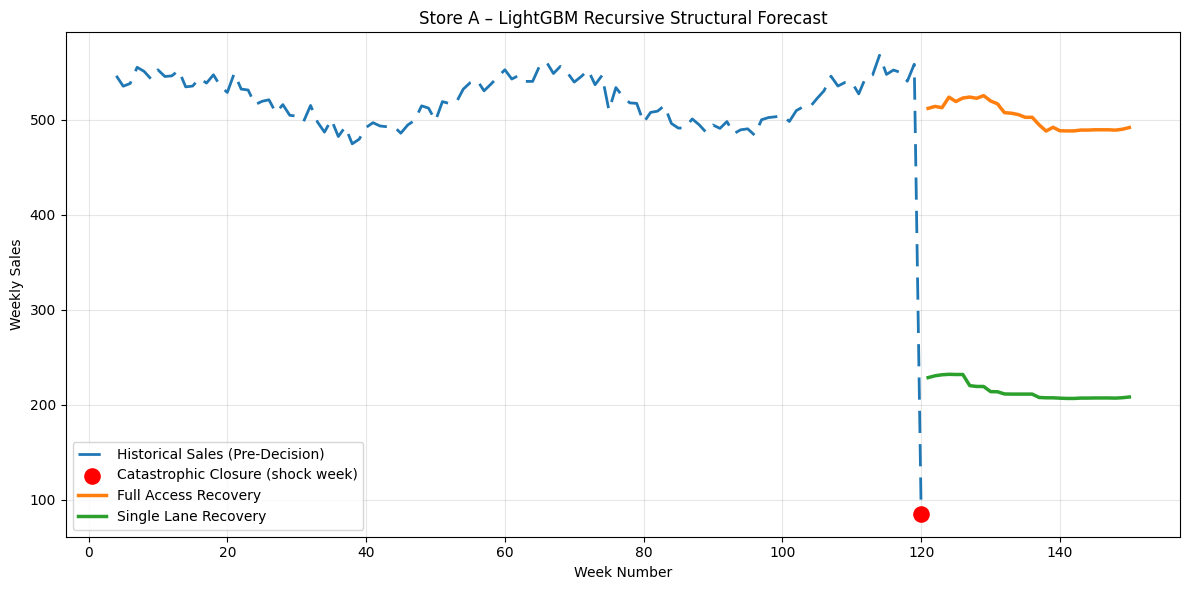

In [4]:
# ==========================================================
# Store A — LightGBM Forecast High Boulevard Disruption
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
store_name = "Store A"
base = 520
weeks_hist = 170
shock_week = shock_week
shock_duration = shock_duration
lane_weeks_hist = partial_weeks
forecast_horizon = 30

closure_drop = 0.90
lane_drop = 0.60

# -----------------------------
# HISTORICAL DATA
# -----------------------------
weeks = np.arange(1, weeks_hist + 1)

access = np.ones(weeks_hist)
access[(weeks >= shock_week) & (weeks < shock_week + shock_duration)] = 0.0
access[(weeks >= shock_week + shock_duration) &
       (weeks <= shock_week + shock_duration + lane_weeks_hist)] = 0.5

seasonality = 30 * np.sin(2 * np.pi * weeks / 52)
noise = np.random.normal(0, 8, weeks_hist)

level = np.full(weeks_hist, base)
level[access == 0.0] = base * (1 - closure_drop)
level[access == 0.5] = base * (1 - lane_drop)

lane_idx = np.where(access == 0.5)[0]
for k, i in enumerate(lane_idx):
    level[i] += min(k * 1.2, base * lane_drop * 0.85)

sales = level + seasonality + noise

df = pd.DataFrame({
    "Week_Num": weeks,
    "access_level": access,
    "Sales": sales
})

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------
df["sin_week"] = np.sin(2*np.pi*df["Week_Num"]/52)
df["cos_week"] = np.cos(2*np.pi*df["Week_Num"]/52)

for lag in [1,2,3]:
    df[f"Lag_{lag}"] = df["Sales"].shift(lag)

df["MA_3"] = df["Sales"].rolling(3).mean()

partial_start = df.loc[df["access_level"]==0.5, "Week_Num"].min()
df["weeks_since_partial"] = np.where(
    df["access_level"]==0.5,
    df["Week_Num"] - partial_start,
    0
)

df = df.dropna().reset_index(drop=True)

baseline_features = ["Week_Num","sin_week","cos_week","Lag_1","Lag_2","Lag_3","MA_3"]
impact_features   = ["access_level","weeks_since_partial"]

# -----------------------------
# TRAIN MODELS
# -----------------------------
baseline_model = LGBMRegressor(random_state=42, n_estimators=500, learning_rate=0.04)
baseline_model.fit(
    df[df["access_level"]==1.0][baseline_features],
    df[df["access_level"]==1.0]["Sales"]
)

df["baseline_pred"] = baseline_model.predict(df[baseline_features])
df["multiplier"] = df["Sales"] / df["baseline_pred"]

impact_model = LGBMRegressor(random_state=42, n_estimators=400, learning_rate=0.05)
impact_model.fit(df[impact_features], df["multiplier"])

print(f"\nMean multiplier by access_level ({store_name}):")
print(df.groupby("access_level")["multiplier"].mean())

# -----------------------------
# RECURSIVE FORECAST FUNCTION
# -----------------------------
def recursive_forecast(seed_df, access_value):
    hist_seed = seed_df[seed_df["Week_Num"] <= shock_week].copy()
    hist_sales = hist_seed["Sales"].tolist()
    future_rows = []

    for step in range(1, forecast_horizon + 1):
        w = shock_week + step

        sin_w = np.sin(2*np.pi*w/52)
        cos_w = np.cos(2*np.pi*w/52)

        lag_1 = hist_sales[-1]
        lag_2 = hist_sales[-2]
        lag_3 = hist_sales[-3]
        ma_3  = np.mean(hist_sales[-3:])

        base_row = pd.DataFrame([{
            "Week_Num": w,
            "sin_week": sin_w,
            "cos_week": cos_w,
            "Lag_1": lag_1,
            "Lag_2": lag_2,
            "Lag_3": lag_3,
            "MA_3":  ma_3
        }])

        baseline_pred = baseline_model.predict(base_row[baseline_features])[0]

        weeks_since_partial = step if access_value == 0.5 else 0
        impact_row = pd.DataFrame([{
            "access_level": access_value,
            "weeks_since_partial": weeks_since_partial
        }])

        mult_pred = impact_model.predict(impact_row[impact_features])[0]
        mult_pred = max(0.05, min(mult_pred, 1.25))

        yhat = baseline_pred * mult_pred

        hist_sales.append(yhat)
        future_rows.append((w, yhat))

    return pd.DataFrame(future_rows, columns=["Week_Num","yhat"])

full_access_fc  = recursive_forecast(df, 1.0)
single_lane_fc  = recursive_forecast(df, 0.5)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

hist_plot = df[df["Week_Num"] <= shock_week]

baseline_dash = (0, (8, 4))

plt.plot(
    hist_plot["Week_Num"], hist_plot["Sales"],
    linestyle=baseline_dash, linewidth=2,
    solid_capstyle="butt", dash_capstyle="butt",
    label="Historical Sales (Pre-Decision)"
)

shock_value = hist_plot.loc[hist_plot["Week_Num"]==shock_week, "Sales"].values[0]

plt.scatter(
    shock_week, shock_value,
    color="red", s=120, zorder=10,
    label="Catastrophic Closure (shock week)"
)

plt.plot(full_access_fc["Week_Num"], full_access_fc["yhat"],
         linewidth=2.5, label="Full Access Recovery")

plt.plot(single_lane_fc["Week_Num"], single_lane_fc["yhat"],
         linewidth=2.5, label="Single Lane Recovery")

plt.title(f"{store_name} – LightGBM Recursive Structural Forecast")
plt.xlabel("Week Number")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**d) Interpretation. Store A: LightGBM Forecast High Boulevard Disruption.**

The model quantifies a severe and persistent demand shock following the disruption event.

- **Full closure impact:** Weekly sales collapse to ~16% of baseline, confirming near-total demand destruction during the shock week.  
- **Partial reopening (0.5):** Recovery stabilizes at ~42–43% of normal demand, indicating that limited access restores only a fraction of revenue capacity.  
- **Full access (1.0):** Sales return close to baseline (~100%), validating that demand is structurally recoverable once mobility constraints are fully removed.  

The widening gap between recovery scenarios highlights **high elasticity of demand to accessibility**. Partial reopening reduces losses but leaves a **~57% structural revenue gap** versus full operations.

From a business perspective:
- Partial operational fixes **mitigate collapse but do not normalize revenue.**
- **Full accessibility restoration is the primary driver of financial recovery.**
- Delays in restoring full access translate directly into **prolonged revenue suppression.**

Overall, this model demonstrates that in high-impact disruptions, **accessibility is not a marginal factor; it is the dominant lever of revenue recovery**.



#### 4.5 LightGBM Forecast – Store B (Moderate-Impact Disruption → Recovery).

Store B represents a moderate disruption scenario, where road construction reduced accessibility but did not fully interrupt operations.

Unlike Store A, this location benefited from **earlier managerial intervention**, enabling a partial reopening (one-lane access) during the disruption period and preserving a portion of customer inflow.

To model this scenario, **LightGBM (Light Gradient Boosting Machine)** is applied using the same structured two-stage design:

- **Baseline Demand Model.**  
  Captures normal weekly sales behavior, including trend, seasonality, and autoregressive momentum through lagged features.

- **Access-Impact Layer.**  
  Estimates the proportional demand adjustments associated with varying levels of accessibility (`access_level`), reflecting the operational impact of constrained mobility.

This framework allows the model to separate:
- **Intrinsic demand patterns** under normal conditions.  
- **Accessibility-driven demand distortions** resulting from operational constraints.  


#### a) Modeling Scope.

The dataset reflects a **moderate shock profile**, where disruption reduces throughput capacity but does not eliminate revenue generation entirely.

Forward simulations focus on realistic recovery pathways under two operational scenarios:

- **Partial Reopening (0.5)**  
  Sustained one-lane access enabling continued, but constrained, operations.  

- **Normal Access (1.0)**  
  Full restoration of road accessibility and operational capacity.  


#### b) Forecasting Strategy.

The model applies **recursive multi-step forecasting** to simulate forward recovery dynamics under each access regime.

This approach captures how demand evolves over time as a function of both:
- Historical sales behavior (lags and momentum).
- Structural accessibility conditions.  


#### c) Analytical Purpose.

This block evaluates how **timely operational intervention alters recovery trajectories under moderate disruption**.

It enables direct quantification of:
- The reduction in revenue loss achieved through partial reopening.  
- The speed of stabilization under constrained access.  
- The incremental benefit of restoring full accessibility.  

Compared to Store A, this scenario highlights how **proactive access management reduces structural demand loss and accelerates financial recovery**.







[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 136, number of used features: 7
[LightGBM] [Info] Start training from score 503.027863
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

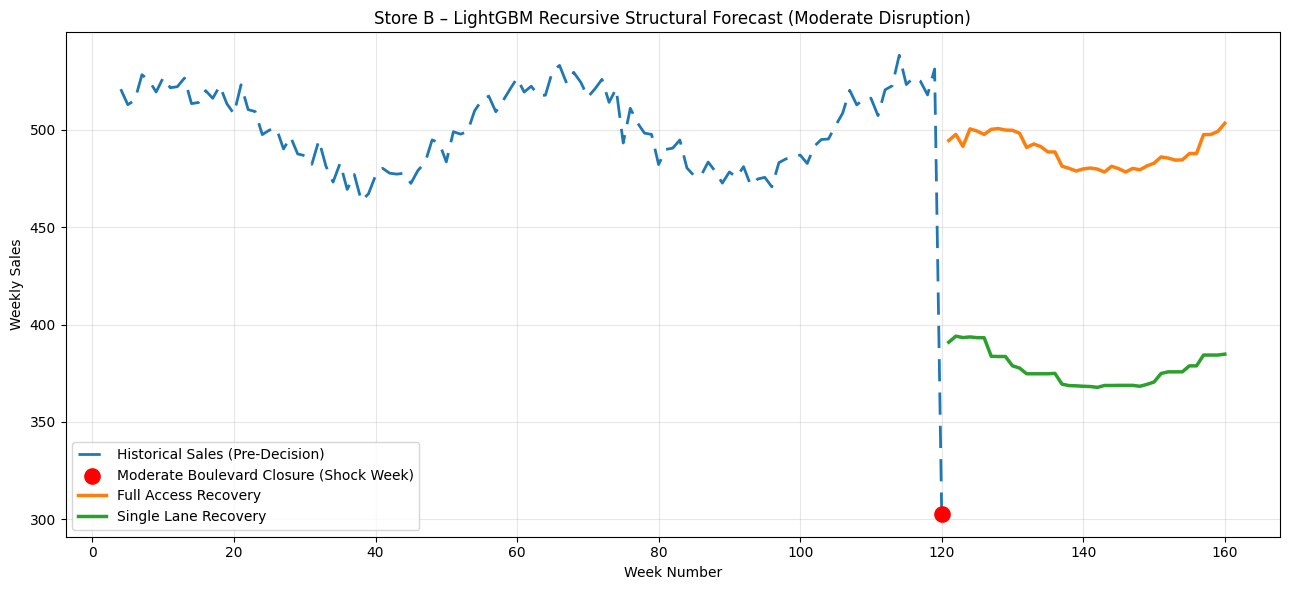

In [5]:
# ==========================================================
# Block 2 – Store B
# LightGBM Forecast – Moderate Boulevard Disruption
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
store_name = "Store B"
base = 500
weeks_hist = 170
shock_week = shock_week
shock_duration = shock_duration
lane_weeks_hist = partial_weeks
forecast_horizon = 40

# Moderate disruption parameters
closure_drop = 0.45
lane_drop    = 0.25

# -----------------------------
# HISTORICAL DATA GENERATION
# -----------------------------
weeks = np.arange(1, weeks_hist + 1)

access = np.ones(weeks_hist)
access[weeks == shock_week] = 0.0
access[(weeks > shock_week) & (weeks <= shock_week + lane_weeks_hist)] = 0.5

seasonality = 25 * np.sin(2 * np.pi * weeks / 52)
noise = np.random.normal(0, 6, weeks_hist)

level = np.full(weeks_hist, base)

level[access == 0.0] = base * (1 - closure_drop)
level[access == 0.5] = base * (1 - lane_drop)

# Smooth partial recovery effect
lane_idx = np.where(access == 0.5)[0]
for k, i in enumerate(lane_idx):
    level[i] += min(k * 0.8, base * lane_drop * 0.6)

sales = level + seasonality + noise

df = pd.DataFrame({
    "Week_Num": weeks,
    "access_level": access,
    "Sales": sales
})

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------
df["sin_week"] = np.sin(2*np.pi*df["Week_Num"]/52)
df["cos_week"] = np.cos(2*np.pi*df["Week_Num"]/52)

for lag in [1, 2, 3]:
    df[f"Lag_{lag}"] = df["Sales"].shift(lag)

df["MA_3"] = df["Sales"].rolling(3).mean()

partial_start = df.loc[df["access_level"]==0.5, "Week_Num"].min()

df["weeks_since_partial"] = np.where(
    df["access_level"]==0.5,
    df["Week_Num"] - partial_start,
    0
)

df = df.dropna().reset_index(drop=True)

baseline_features = ["Week_Num","sin_week","cos_week",
                     "Lag_1","Lag_2","Lag_3","MA_3"]

impact_features = ["access_level","weeks_since_partial"]

# -----------------------------
# TRAIN BASELINE MODEL (Normal Access Only)
# -----------------------------
baseline_model = LGBMRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.04
)

baseline_model.fit(
    df[df["access_level"]==1.0][baseline_features],
    df[df["access_level"]==1.0]["Sales"]
)

df["baseline_pred"] = baseline_model.predict(df[baseline_features])
df["multiplier"] = df["Sales"] / df["baseline_pred"]

# -----------------------------
# TRAIN IMPACT MODEL
# -----------------------------
impact_model = LGBMRegressor(
    random_state=42,
    n_estimators=400,
    learning_rate=0.05
)

impact_model.fit(df[impact_features], df["multiplier"])

print(f"\nMean multiplier by access_level ({store_name}):")
print(df.groupby("access_level")["multiplier"].mean())

# -----------------------------
# RECURSIVE FORECAST FUNCTION
# -----------------------------
def recursive_forecast(seed_df, access_value):

    hist_seed = seed_df[seed_df["Week_Num"] <= shock_week].copy()
    hist_sales = hist_seed["Sales"].tolist()
    future_rows = []

    for step in range(1, forecast_horizon + 1):

        w = shock_week + step

        sin_w = np.sin(2*np.pi*w/52)
        cos_w = np.cos(2*np.pi*w/52)

        lag_1 = hist_sales[-1]
        lag_2 = hist_sales[-2]
        lag_3 = hist_sales[-3]
        ma_3  = np.mean(hist_sales[-3:])

        base_row = pd.DataFrame([{
            "Week_Num": w,
            "sin_week": sin_w,
            "cos_week": cos_w,
            "Lag_1": lag_1,
            "Lag_2": lag_2,
            "Lag_3": lag_3,
            "MA_3":  ma_3
        }])

        baseline_pred = baseline_model.predict(
            base_row[baseline_features]
        )[0]

        weeks_since_partial = step if access_value==0.5 else 0

        impact_row = pd.DataFrame([{
            "access_level": access_value,
            "weeks_since_partial": weeks_since_partial
        }])

        mult_pred = impact_model.predict(
            impact_row[impact_features]
        )[0]

        mult_pred = max(0.05, min(mult_pred, 1.25))

        yhat = baseline_pred * mult_pred

        hist_sales.append(yhat)
        future_rows.append((w, yhat))

    return pd.DataFrame(future_rows, columns=["Week_Num","yhat"])


# Generate scenarios
full_access_fc  = recursive_forecast(df, 1.0)
single_lane_fc  = recursive_forecast(df, 0.5)

# -----------------------------
# CLEAN EXECUTIVE PLOT
# -----------------------------
plt.figure(figsize=(13,6))

# Historical ONLY until shock
hist_plot = df[df["Week_Num"] <= shock_week]

baseline_dash = (0, (8, 4))

plt.plot(
    hist_plot["Week_Num"],
    hist_plot["Sales"],
    linestyle=baseline_dash,
    linewidth=2,
    solid_capstyle="butt",
    dash_capstyle="butt",
    label="Historical Sales (Pre-Decision)"
)

# Shock value
shock_value = hist_plot.loc[
    hist_plot["Week_Num"]==shock_week, "Sales"
].values[0]

# Shock marker only
plt.scatter(
    shock_week,
    shock_value,
    color="red",
    s=120,
    zorder=10,
    label="Moderate Boulevard Closure (Shock Week)"
)

# Forecast branches
plt.plot(
    full_access_fc["Week_Num"],
    full_access_fc["yhat"],
    linewidth=2.5,
    label="Full Access Recovery"
)

plt.plot(
    single_lane_fc["Week_Num"],
    single_lane_fc["yhat"],
    linewidth=2.5,
    label="Single Lane Recovery"
)

plt.title("Store B – LightGBM Recursive Structural Forecast (Moderate Disruption)")
plt.xlabel("Week Number")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**d) Interpretation. Store B: LightGBM Forecast Moderate Boulevard Disruption.**

The model reflects a **moderate but contained disruption**, where accessibility constraints reduce revenue without fully collapsing demand.

- **Shock impact:** Weekly sales decline to ~61% of baseline during the disruption, confirming a significant but non-catastrophic contraction.  
- **Partial reopening (0.5):** Sales stabilize at ~77% of baseline, demonstrating that early access restoration preserves a substantial portion of revenue capacity.  
- **Full access (1.0):** Sales return to baseline (~100%), indicating that underlying demand remains structurally intact.  

The relatively narrow gap between recovery scenarios highlights **lower demand sensitivity to accessibility constraints** compared to Store A.

From a business perspective:
- Early intervention **limits the depth of revenue loss** during disruption.  
- Partial reopening delivers **meaningful financial recovery**, not just mitigation.  
- The remaining ~23% revenue gap under constrained access represents **manageable but persistent exposure.**  

Overall, this model shows that under moderate disruptions, **operational responsiveness materially improves recovery outcomes and reduces financial risk**, even before full accessibility is restored.

### 4.6 Prophet Forecasting.

Prophet is applied to model the **structural impact of accessibility disruptions on demand over time**, complementing the machine learning approach with an interpretable time-series framework.

Unlike LightGBM, which focuses on short-term dynamics, Prophet decomposes demand into **trend, seasonality, and exogenous accessibility effects**, enabling direct estimation of how operational constraints alter the underlying demand trajectory.

This approach supports **scenario-based recovery analysis**, allowing comparison of demand evolution under different accessibility regimes while preserving long-term structural relationships.

***Note:** Percentages in this section represent model-implied demand multipliers (structural outputs). Financial impact is quantified separately in the Key Results section using absolute revenue differences (MXN and USD).*


### 4.7 Prophet Forecast. Store A: (Severe Disruption → Structural Recovery).

Store A represents a **severe disruption scenario**, where road construction resulted in a full accessibility breakdown followed by a constrained recovery phase.

During the shock period, customer inflow was effectively eliminated, generating a sharp deviation from baseline demand. Access was later partially restored through limited-lane reopening before returning to normal operational conditions.

To model this behavior, **Prophet (Additive Time-Series Model)** is applied using a structural specification that integrates accessibility conditions directly into the demand equation.

The model decomposes demand into three core components:

- **Trend Component.**  
  Captures the long-term structural evolution of demand before and after disruption.  

- **Seasonality Component.**  
  Models recurring weekly patterns to isolate cyclical fluctuations.  

- **Exogenous Regressors.**  
  Incorporates operational variables (`access_level`, `shock_intensity`, `weeks_since_partial`) to quantify regime-dependent demand shifts.  

This formulation allows the model to distinguish between:
- **Baseline structural demand dynamics.**
- **Accessibility-driven demand distortions.**
- **Recovery persistence following disruption.**


#### a) Modeling Scope.

The dataset reflects a **catastrophic accessibility shock**, followed by phased recovery conditions.

Forward simulations evaluate two operational scenarios:

- **Single Lane Recovery (0.5)**  
  Partial reopening with constrained throughput capacity.  

- **Full Access Recovery (1.0)**  
  Complete restoration of mobility and operational conditions.  


#### b) Forecasting Strategy.

The model is trained on the full historical dataset, including disruption periods, allowing accessibility effects to be learned directly from observed data.

Future scenarios are generated by modifying accessibility conditions while preserving learned structural relationships, enabling **counterfactual comparison of recovery paths.**


#### c) Analytical Purpose.

This block evaluates how **severe accessibility constraints impact long-term demand recovery**.

It enables quantification of:
- The depth of structural demand contraction.  
- The persistence of revenue suppression under partial reopening.  
- The role of full accessibility restoration in re-establishing baseline demand.  

This scenario establishes the **high-impact benchmark** for the Saltillo disruption, enabling direct comparison with moderate-impact dynamics observed in Store B.


Regressors in model: ['access_level', 'shock_intensity', 'weeks_since_partial']

Early (Weeks 1–4) lane vs full multiplier: 0.427
Long-run (Last 10 Weeks) lane vs full multiplier: 0.443
Long-run implied demand reduction: 55.7%


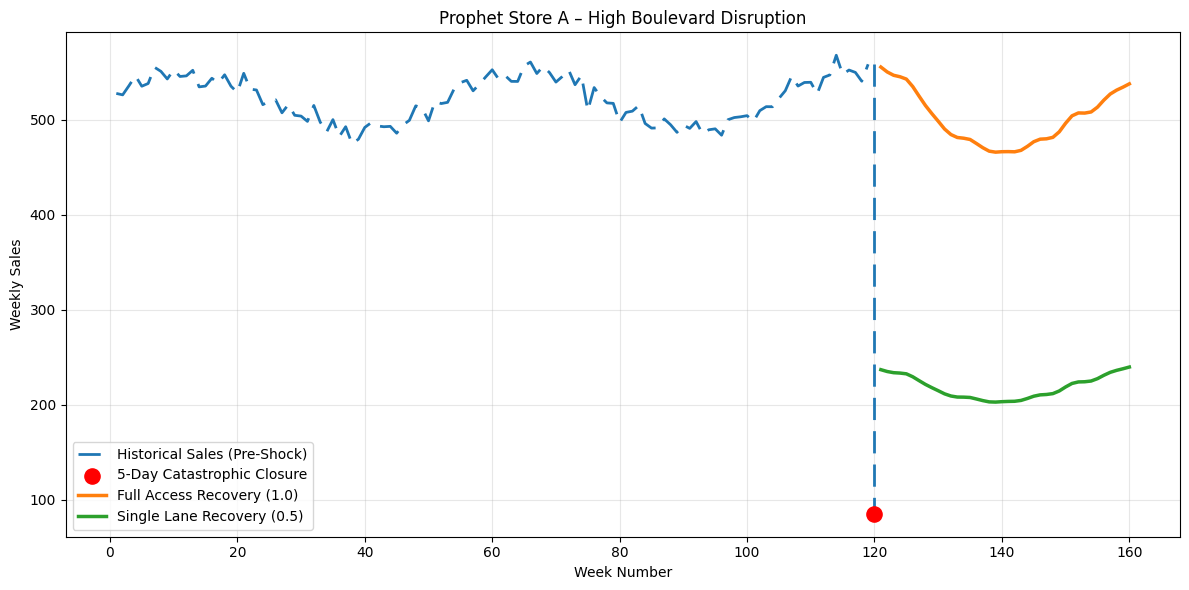

In [6]:
# ==========================================================
# Prophet Forecasting – Store A High Boulevard Disruption
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
weeks_total = 170
shock_week = shock_week
lane_weeks = partial_weeks
forecast_horizon = 40
base = 520

closure_drop = 0.90
lane_drop = 0.60

weeks = np.arange(1, weeks_total + 1)
dates = pd.date_range(start="2020-01-05", periods=weeks_total, freq="W")

# -----------------------------
# ACCESS REGIME HISTORY
# -----------------------------
access = np.ones(weeks_total)
access[weeks == shock_week] = 0.0
access[(weeks > shock_week) & (weeks <= shock_week + lane_weeks)] = 0.5
access[(weeks > shock_week + lane_weeks)] = 1.0

# -----------------------------
# SYNTHETIC SALES
# -----------------------------
seasonality = 30 * np.sin(2 * np.pi * weeks / 52)
noise = np.random.normal(0, 8, weeks_total)

level = np.full(weeks_total, base)
level[access == 0.0] = base * (1 - closure_drop)
level[access == 0.5] = base * (1 - lane_drop)

lane_idx = np.where(access == 0.5)[0]
for k, i in enumerate(lane_idx):
    level[i] += min(k * 1.2, base * lane_drop * 0.85)

sales = np.maximum(level + seasonality + noise, 1.0)

df = pd.DataFrame({
    "ds": dates,
    "Week_Num": weeks,
    "Sales": sales,
    "access_level": access
})

# -----------------------------
# STRUCTURAL REGRESSORS
# -----------------------------
df["shock_intensity"] = 0.0
df.loc[df["Week_Num"] == shock_week, "shock_intensity"] = 1.0
df.loc[df["Week_Num"] == shock_week + 1, "shock_intensity"] = 0.3

partial_start = df.loc[df["access_level"] == 0.5, "Week_Num"].min()
df["weeks_since_partial"] = np.where(
    df["access_level"] == 0.5,
    df["Week_Num"] - partial_start,
    0
)

df["y"] = np.log(df["Sales"])

# -----------------------------
# MODEL TRAINING (Full Dataset)
# -----------------------------
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.25,
    seasonality_prior_scale=10.0
)

m.add_regressor("access_level", prior_scale=10.0, standardize=True)
m.add_regressor("shock_intensity", prior_scale=30.0, standardize=False)
m.add_regressor("weeks_since_partial", prior_scale=5.0, standardize=False)

m.fit(df[["ds","y","access_level","shock_intensity","weeks_since_partial"]])

print("\nRegressors in model:", list(m.extra_regressors.keys()))

# -----------------------------
# COUNTERFACTUAL FUTURE SCENARIOS
# -----------------------------
future_weeks = np.arange(shock_week + 1, shock_week + forecast_horizon + 1)

future_ds = pd.date_range(
    start=df.loc[df["Week_Num"] == shock_week, "ds"].iloc[0] + pd.Timedelta(weeks=1),
    periods=forecast_horizon,
    freq="W"
)

def make_future_scenario(access_value):
    fut = pd.DataFrame({
        "ds": future_ds,
        "access_level": access_value,
        "shock_intensity": 0.0
    })
    if access_value == 0.5:
        fut["weeks_since_partial"] = np.arange(1, forecast_horizon + 1)
    else:
        fut["weeks_since_partial"] = 0
    return fut

future_full = make_future_scenario(1.0)
future_lane = make_future_scenario(0.5)

fc_full = m.predict(future_full)
fc_lane = m.predict(future_lane)

yhat_full = np.exp(fc_full["yhat"].values)
yhat_lane = np.exp(fc_lane["yhat"].values)

# -----------------------------
# MODEL-IMPLIED MULTIPLIERS
# -----------------------------
lane_vs_full = yhat_lane / yhat_full

early_ratio = float(np.mean(lane_vs_full[:4]))      # Weeks 1–4
long_ratio  = float(np.mean(lane_vs_full[-10:]))    # Last 10 weeks
long_reduction_pct = float((1 - long_ratio) * 100)

print(f"\nEarly (Weeks 1–4) lane vs full multiplier: {early_ratio:.3f}")
print(f"Long-run (Last 10 Weeks) lane vs full multiplier: {long_ratio:.3f}")
print(f"Long-run implied demand reduction: {long_reduction_pct:.1f}%")

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

# Historical line (Blue dashed, pre-shock only)
hist_pre = df[df["Week_Num"] < shock_week]
plt.plot(
    hist_pre["Week_Num"],
    np.exp(hist_pre["y"]),
    color="tab:blue",
    linestyle=(0,(8,4)),
    linewidth=2,
    label="Historical Sales (Pre-Shock)"
)

# Shock + controlled vertical segment (Blue dashed)
shock_y = float(np.exp(df.loc[df["Week_Num"] == shock_week, "y"].values[0]))
prev_y  = float(np.exp(df.loc[df["Week_Num"] == shock_week - 1, "y"].values[0]))

plt.plot(
    [shock_week, shock_week],
    [prev_y, shock_y],
    color="tab:blue",
    linestyle=(0,(8,4)),
    linewidth=2
)

# Shock marker (Red)
plt.scatter(
    shock_week, shock_y,
    color="red", s=120, zorder=5,
    label="5-Day Catastrophic Closure"
)

# Forecast branches (Orange = full, Green = lane)
plt.plot(
    future_weeks, yhat_full,
    color="tab:orange",
    linewidth=2.5,
    label="Full Access Recovery (1.0)"
)

plt.plot(
    future_weeks, yhat_lane,
    color="tab:green",
    linewidth=2.5,
    label="Single Lane Recovery (0.5)"
)

plt.title("Prophet Store A – High Boulevard Disruption")
plt.xlabel("Week Number")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**d) Interpretation. Prophet: Store A. Severe Boulevard Disruption.**

The model captures a **severe and persistent structural demand contraction** driven by extreme accessibility constraints.

- **Shock impact:** Sales collapse during the disruption, reflecting near-total loss of customer inflow under full closure conditions.  
- **Partial reopening (0.5):** Early recovery stabilizes at ~42.7% of baseline, with long-run stabilization around ~44.3%, indicating that limited accessibility restores less than half of normal demand.  
- **Full access (1.0):** Sales progressively return toward baseline, confirming that underlying demand remains structurally recoverable once constraints are removed.  

The stability of the partial-access trajectory highlights a **persistent structural revenue gap of ~55–56%**, driven by constrained throughput rather than temporary volatility.

From a business perspective:
- Partial reopening **mitigates immediate collapse but does not normalize revenue.**
- The sustained gap reflects **capacity limitations, not demand disappearance.**  
- Full accessibility restoration is required to **recover the long-term demand trajectory.**  

Importantly, the smooth recovery curves reflect Prophet’s structural decomposition, where adjustments occur through **gradual trend rebalancing rather than recursive short-term effects**.

Overall, this model shows that under severe disruptions, **accessibility constraints create lasting structural revenue loss, and only full operational restoration enables true recovery**.

### 4.8 Prophet Forecast. Store B: (Moderate Disruption → Structural Recovery).

Store B represents a **moderate disruption scenario**, where road construction reduced accessibility but did not fully eliminate customer inflow.

Unlike Store A, this location benefited from **earlier operational intervention**, enabling partial lane access during the disruption period and preserving a portion of revenue generation.

To model this behavior, **Prophet (Additive Time-Series Model)** is applied using a structural specification that incorporates accessibility conditions directly into the demand equation.

The model decomposes demand into three core components:

- **Trend Component.**  
  Captures the long-term structural evolution of demand under moderate disruption.  

- **Seasonality Component.**  
  Models recurring weekly demand patterns, isolating cyclical effects from structural changes.  

- **Exogenous Regressors.**  
  Integrates operational variables (`access_level`, `shock_intensity`, `weeks_since_partial`) to estimate regime-dependent demand adjustments and recovery persistence.  

This formulation enables the model to distinguish between:
- **Underlying structural demand stability.**
- **Accessibility-driven demand reductions.**
- **Gradual recovery dynamics following intervention.**


#### a) Modeling Scope.

The dataset reflects a **moderate accessibility shock**, where demand is reduced but not fully suppressed.

Forward simulations evaluate two operational recovery scenarios:

- **Partial Reopening (0.5)**  
  Continued one-lane access allowing constrained but stable operations.  

- **Normal Access (1.0)**  
  Full restoration of mobility and operational capacity.  


#### b) Forecasting Strategy.

The model is trained on the full historical dataset, including both disruption and partial recovery phases, allowing accessibility effects to be learned directly from observed behavior.

Future scenarios are generated by modifying accessibility conditions while preserving learned structural relationships, enabling **counterfactual comparison of recovery paths**.


#### c) Analytical Purpose.

This block evaluates how **moderate accessibility constraints influence recovery speed and revenue stabilization**.

It enables quantification of:
- The degree of demand contraction under partial disruption.  
- The effectiveness of early intervention in preserving revenue.  
- The incremental benefit of restoring full accessibility.  

Compared to Store A, this scenario highlights how **proactive operational response reduces structural demand loss and accelerates financial recovery under moderate disruption conditions**.


Regressors in model: ['access_level', 'shock_intensity', 'weeks_since_partial']

Model-implied average lane vs full multiplier: 0.730
Implied demand reduction under lane scenario: 27.0%


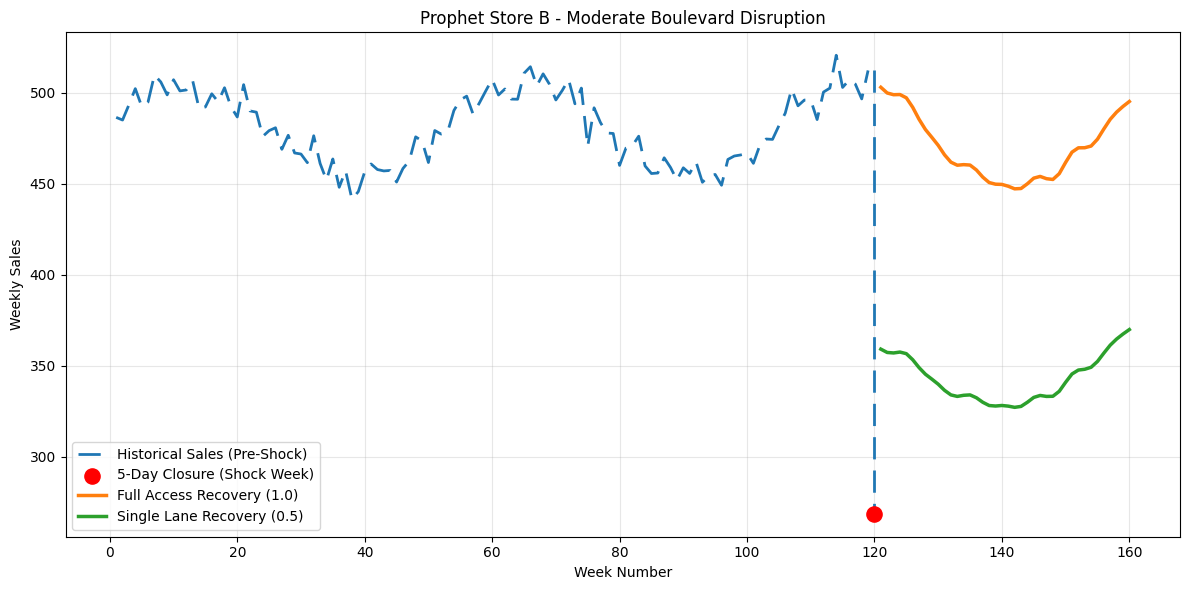

In [7]:
# ==========================================================
# Structural Prophet – Store B Moderate Boulevard Disruption
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
weeks_total = 170
shock_week = shock_week
lane_weeks = partial_weeks
forecast_horizon = 40
base = 480

closure_drop = 0.50
lane_drop = 0.30

weeks = np.arange(1, weeks_total + 1)
dates = pd.date_range(start="2020-01-05", periods=weeks_total, freq="W")

# -----------------------------
# ACCESS REGIME HISTORY
# -----------------------------
access = np.ones(weeks_total)
access[weeks == shock_week] = 0.0
access[(weeks > shock_week) & (weeks <= shock_week + lane_weeks)] = 0.5
access[(weeks > shock_week + lane_weeks)] = 1.0

# -----------------------------
# SYNTHETIC SALES
# -----------------------------
seasonality = 25 * np.sin(2 * np.pi * weeks / 52)
noise = np.random.normal(0, 7, weeks_total)

level = np.full(weeks_total, base)
level[access == 0.0] = base * (1 - closure_drop)
level[access == 0.5] = base * (1 - lane_drop)

lane_idx = np.where(access == 0.5)[0]
for k, i in enumerate(lane_idx):
    level[i] += min(k * 0.8, base * lane_drop * 0.75)

sales = np.maximum(level + seasonality + noise, 1.0)

df = pd.DataFrame({
    "ds": dates,
    "Week_Num": weeks,
    "Sales": sales,
    "access_level": access
})

# -----------------------------
# STRUCTURAL REGRESSORS
# -----------------------------
df["shock_intensity"] = 0.0
df.loc[df["Week_Num"] == shock_week, "shock_intensity"] = 1.0

partial_start = df.loc[df["access_level"] == 0.5, "Week_Num"].min()
df["weeks_since_partial"] = np.where(
    df["access_level"] == 0.5,
    df["Week_Num"] - partial_start,
    0
)

df["y"] = np.log(df["Sales"])

# -----------------------------
# FULL DATASET TRAINING
# -----------------------------
df_train = df.copy()

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.25,
    seasonality_prior_scale=10.0
)

m.add_regressor("access_level", prior_scale=10.0, standardize=True)
m.add_regressor("shock_intensity", prior_scale=20.0, standardize=False)
m.add_regressor("weeks_since_partial", prior_scale=5.0, standardize=False)

m.fit(df_train[["ds","y","access_level","shock_intensity","weeks_since_partial"]])

print("\nRegressors in model:", list(m.extra_regressors.keys()))

# -----------------------------
# FUTURE COUNTERFACTUALS
# -----------------------------
future_weeks = np.arange(shock_week + 1, shock_week + forecast_horizon + 1)

future_ds = pd.date_range(
    start=df.loc[df["Week_Num"] == shock_week, "ds"].iloc[0] + pd.Timedelta(weeks=1),
    periods=forecast_horizon,
    freq="W"
)

def make_future_scenario(access_value):
    fut = pd.DataFrame({
        "ds": future_ds,
        "access_level": access_value,
        "shock_intensity": 0.0
    })

    if access_value == 0.5:
        fut["weeks_since_partial"] = np.arange(1, forecast_horizon + 1)
    else:
        fut["weeks_since_partial"] = 0

    return fut

future_full = make_future_scenario(1.0)
future_lane = make_future_scenario(0.5)

fc_full = m.predict(future_full)
fc_lane = m.predict(future_lane)

yhat_full = np.exp(fc_full["yhat"].values)
yhat_lane = np.exp(fc_lane["yhat"].values)

# -----------------------------
# MODEL-IMPLIED ELASTICITY
# -----------------------------
impact_ratio = np.mean(yhat_lane / yhat_full)

print(f"\nModel-implied average lane vs full multiplier: {impact_ratio:.3f}")
print(f"Implied demand reduction under lane scenario: {(1 - impact_ratio)*100:.1f}%")

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

hist_pre = df[df["Week_Num"] < shock_week]

plt.plot(
    hist_pre["Week_Num"],
    np.exp(hist_pre["y"]),
    color="tab:blue",
    linestyle=(0,(8,4)),
    linewidth=2,
    label="Historical Sales (Pre-Shock)"
)

shock_y = float(np.exp(df.loc[df["Week_Num"] == shock_week, "y"].values[0]))
prev_y  = float(np.exp(df.loc[df["Week_Num"] == shock_week - 1, "y"].values[0]))

plt.plot(
    [shock_week, shock_week],
    [prev_y, shock_y],
    color="tab:blue",
    linestyle=(0,(8,4)),
    linewidth=2
)

plt.scatter(
    shock_week, shock_y,
    color="red", s=120, zorder=5,
    label="5-Day Closure (Shock Week)"
)

plt.plot(
    future_weeks, yhat_full,
    color="tab:orange",
    linewidth=2.5,
    label="Full Access Recovery (1.0)"
)

plt.plot(
    future_weeks, yhat_lane,
    color="tab:green",
    linewidth=2.5,
    label="Single Lane Recovery (0.5)"
)

plt.title("Prophet Store B - Moderate Boulevard Disruption")
plt.xlabel("Week Number")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**d) Interpretation. Prophet: Store B Moderate Boulevard Disruption.**

The model captures a **moderate and controlled demand contraction**, where accessibility constraints reduce revenue without disrupting underlying demand stability.

- **Shock impact:** Sales decline during the disruption but remain operational, reflecting partial preservation of customer inflow.  
- **Partial reopening (0.5):** Early recovery stabilizes at ~73% of baseline demand, indicating that limited accessibility retains a significant portion of revenue capacity.  
- **Full access (1.0):** Sales return to baseline, confirming that demand remains structurally intact under moderate disruption conditions.  

The model estimates a **long-run demand reduction of ~27%** under constrained access, highlighting a measurable but manageable structural revenue gap.

From a business perspective:
- Partial reopening delivers **substantial revenue protection**, not just short-term mitigation.  
- The remaining gap reflects **throughput limitations rather than demand loss.**  
- Full accessibility restoration enables complete normalization of the demand trajectory.  

The smooth recovery reflects structural trend adjustment rather than short-term volatility, consistent with Prophet’s additive framework.

Overall, this model shows that under moderate disruptions, **early accessibility restoration significantly reduces financial exposure and accelerates recovery, even before full operational conditions are restored**.

### 4.9 Summary of Approach.

This approach models how accessibility disruptions translate into measurable demand changes and recovery dynamics under different operational conditions.

A dual-framework methodology was applied to ensure both **predictive strength and structural interpretability**.

- **LightGBM** captures short-term demand response, nonlinear effects, and momentum through recursive forecasting.  
- **Prophet** decomposes demand into trend, seasonality, and accessibility-driven components, enabling direct estimation of structural impact.  

Both models are trained on a unified dataset with accessibility regimes, disruption signals, recovery progression, and temporal demand features.

This ensures results reflect consistent patterns across methodologies rather than model-specific artifacts.

The modeling strategy follows a controlled sequence:
1. Learn baseline demand under normal operating conditions.  
2. Introduce disruption through accessibility constraints.  
3. Simulate recovery under partial and full access scenarios.  

This structure allows direct comparison of how demand behaves under different levels of operational accessibility.

The key technical contribution is the explicit separation between intrinsic demand dynamics and accessibility-driven effects.

The analysis produces, combining both perspectives:
- Stable and consistent recovery patterns across models.  
- Quantifiable differences between disruption regimes.  
- A reliable basis for scenario comparison under controlled assumptions.  

Overall, this approach transforms time-series modeling into a scenario-based analytical framework, enabling clear evaluation of disruption impact and recovery behavior without relying on arbitrary assumptions or manual scaling.

## 5. Key Results.

The analysis shows that accessibility is the dominant driver of weekly revenue performance across both disruption profiles.

### 5.1 Weekly Revenue Exposure.

The initial closure creates an immediate and material revenue shock in both stores, but the severity differs sharply by exposure level.

- **Store A (Severe Exposure)**
  - Baseline weekly revenue: **MXN 521,340 (~USD 30,670)**
  - Full-closure revenue: **MXN 86,070 (~USD 5,060)**
  - Weekly revenue loss under full closure: **MXN 435,270 (~USD 25,600)**

- **Store B (Moderate Exposure)**
  - Baseline weekly revenue: **MXN 502,560 (~USD 29,560)**
  - Full-closure revenue: **MXN 173,070 (~USD 10,180)**
  - Weekly revenue loss under full closure: **MXN 329,490 (~USD 19,380)**

This shows that Store A is materially more vulnerable to direct access disruption, while Store B retains a larger portion of baseline demand under the same shock event.

### 5.2 Value of Partial Reopening.

Partial reopening does not restore normal performance, but materially reduces weekly losses in both cases.

- **Store A**
  - Partial-reopening revenue: **MXN 287,590 (~USD 16,920)**
  - Weekly loss under partial access: **MXN 233,750 (~USD 13,750)**
  - Revenue protected vs. full closure: **46.30%**
  - Weekly value preserved vs. full closure: **MXN 201,520 (~USD 11,860)**

- **Store B**
  - Partial-reopening revenue: **MXN 352,280 (~USD 20,720)**
  - Weekly loss under partial access: **MXN 150,280 (~USD 8,840)**
  - Revenue protected vs. full closure: **54.39%**
  - Weekly value preserved vs. full closure: **MXN 179,210 (~USD 10,540)**

**Partial reopening does not restore normal performance. Instead, it establishes a measurable revenue floor while full access is being restored.**

### 5.3 Structural Difference Between Severe and Moderate Disruption.

The two-store comparison makes the operating reality clear:

- **Store A behaves like a high-exposure asset** with strong dependence on direct mobility flow.
- **Store B shows greater resilience,** with lower downside under closure and stronger retention under partial access.

This is not a cosmetic difference, it materially changes the economic value of intervention.

### 5.4 Cross-Model Confirmation.

Both forecasting frameworks, LightGBM and Prophet, converge on the same conclusion:

- Severe disruption produces a deep and persistent revenue gap under constrained access.
- Moderate disruption remains financially damaging, but materially more recoverable.
- **Full accessibility restoration is the only condition that returns demand to baseline.**

### 5.5 Weekly Revenue Loss by Scenario.

| Scenario                 | Store A Loss % | Store A Weekly Loss              | Store B Loss % | Store B Weekly Loss              |
|-------------------------|----------------|----------------------------------|----------------|----------------------------------|
| Full Closure            | 84%            | MXN 435,270 (~USD 25,600)        | 66%            | MXN 329,490 (~USD 19,380)        |
| Partial Reopening (0.5) | 45%            | MXN 233,750 (~USD 13,750)        | 30%            | MXN 150,280 (~USD 8,840)         |
| Full Access (1.0)       | 0%             | MXN 0 (~USD 0)                   | 0%             | MXN 0 (~USD 0)                   |


### 5.6 Executive Takeaway.

Accessibility is not a binary condition; it is a **quantifiable economic lever with measurable weekly impact.**

- Partial reopening consistently establishes a **revenue floor**, preserving approximately **USD 10,540–11,860 per week per location**.

- However, the residual gap remains structurally significant, particularly in high-exposure sites.
- The magnitude of loss is **location-sensitive,** meaning identical disruptions generate materially different financial outcomes across assets.

The implication is clear:

**Access management is not an operational detail; it is a revenue control mechanism that must be actively optimized, not passively restored.**

## 6. Operational Implications.

### 6.1 Accessibility Is an Operational Responsibility, Not an External Constraint.

The analysis demonstrates that revenue impact during disruption is not driven solely by the event itself, but by how access is operationally managed.

- Full closure represents a worst-case scenario, not an inevitability  
- Partial access, when actively secured, materially reduces revenue destruction.  
- Accessibility must therefore be treated as a **controllable operational variable.**


### 6.2 Quantified Value of Intervention.

Operational actions taken during the disruption translated directly into measurable financial outcomes:

**- Store A: MXN 201,520 (~USD 11,860) weekly revenue preserved**  
**- Store B: MXN 179,210 (~USD 10,540) weekly revenue preserved**  

These outcomes confirm that intervention is economically material, not operationally cosmetic.


### 6.3 Execution Converts Access into Revenue.

Access alone does not guarantee recovery. Revenue stabilization required coordinated execution:

- Physical routing to ensure safe and visible entry.  
- Clear on-site signaling to maintain customer awareness.  
- Targeted promotions to reactivate demand.  

These actions transformed constrained accessibility into **actual customer flow and revenue capture.**


### 6.4 Timing Drives Outcome Magnitude.

The contrast between Store A and Store B highlights a critical operational principle:

- Delayed response results in deeper and more persistent revenue contraction.  
- Early intervention limits downside and accelerates stabilization.  
- The same structural shock produces **different financial outcomes depending on response timing.**

Execution speed is therefore a primary driver of revenue resilience.


### 6.5 Partial Access Defines the Revenue Floor, Not the Recovery Ceiling.

Partial reopening establishes a stabilized operating state:

- It prevents full revenue collapse.  
- It establishes a measurable and predictable revenue floor.
- It does not restore baseline performance.  

Sustained recovery remains structurally dependent on full accessibility restoration.


### 6.6 Standardization of Disruption Response.

The observed outcomes support the need for a repeatable operational model:

- Rapid access negotiation with authorities.  
- Immediate deployment of visibility and routing measures.  
- Activation of localized commercial actions.  

This transforms disruption management from reactive behavior into a **repeatable operational capability.**


### 6.7 Strategic Implication.

The results establish a clear operational truth:

Revenue performance during infrastructure disruption is not defined by the disruption itself,  
but by the organization’s ability to **secure access, execute quickly, and convert that access into demand**.

### 6.8 Operational Conclusion. Direct Actions and Managerial Response (2010 Saltillo Case).

The 2010 boulevard closure was not managed passively. Once limited lane access was negotiated with the Municipal Public Works Department, immediate operational measures were implemented to convert constrained accessibility into stabilized revenue flow.

The negotiated single-lane access was physically delimited with certified orange safety cones, ensuring compliance with municipal safety regulations while maintaining controlled vehicle entry and preserving minimum throughput capacity.

Visibility was aggressively reinforced. A large banner was installed at the lane entrance announcing continued station operation, supported by additional promotional signage along the access corridor to reduce uncertainty and restore traffic confidence.

Commercial strategy shifted toward active demand stimulation. Two targeted promotional actions proved especially effective:

- **Household-focused cookware (“pans”) promotion**. **Discounted nearly 40%** below the already active corporate campaign price, increasing basket size in residential trade areas.

- **Cinema ticket promotion**. Offered at an **additional 20% discount** versus standard pricing, driving incremental visits and supporting cross-traffic recovery.

These interventions did not eliminate revenue contraction. However, they materially reduced financial exposure and accelerated stabilization under partial-access conditions.

From an analytical perspective, this operational reality aligns directly with the model’s structural findings:

- **Accessibility functions** as the dominant elasticity driver of revenue variation.
- **Partial mobility** preserves a measurable revenue floor.
- **Active operational execution** influences recovery slope but cannot fully override structural access constraints.

The modeling results should therefore be interpreted not as abstract forecast curves, but as quantitative representations of real managerial leverage under constrained infrastructure conditions.



## 7. Business Value.

This project converts a localized road-access disruption into a **decision-ready revenue framework**.

Its value is not limited to forecasting sales. The real value lies in making three business questions measurable:

- How much revenue is exposed under full closure?
- How much can be preserved through partial reopening?
- Which locations justify faster operational escalation because their downside is materially larger?

### 7.1 Quantifies Revenue at Risk.

The analysis turns accessibility loss into a measurable weekly financial exposure.

- **Store A:** full closure destroys approximately **MXN 435,270 (~USD 25,600) per week.**
- **Store B:** full closure destroys approximately **MXN 329,490 (~USD 19,380) per week.**

This gives leadership a concrete way to size disruption impact, prioritize response, and avoid treating all affected sites as operationally equivalent.

### 7.2 Measures the Economic Value of Intervention.

The project demonstrates that operational action creates measurable financial protection.

- **Store A:** partial reopening preserves approximately **MXN 201,520 (~USD 11,860) per week.**
- **Store B:** partial reopening preserves approximately **MXN 179,210 (~USD 10,540) per week.**

This reframes intervention from a reactive operational effort into a financially justified action with observable return.

### 7.3 Distinguishes High-Exposure from Moderate-Exposure Assets.

One of the strongest contributions of the analysis is that it separates locations by **structural vulnerability**.

- **Store A** behaves as a high-exposure site with severe dependence on direct traffic flow.
- **Store B** shows greater buffering capacity under constrained access.

This distinction is commercially important. It means response strategy should not be standardized blindly.  
Some sites require immediate escalation because every week of delay carries materially higher economic cost.

### 7.4 Supports Better Capital and Operational Prioritization.

The models provide a basis for deciding where to intervene first, where partial access is sufficient as a temporary bridge, and where full restoration must be accelerated.

In practice, this supports:

- Faster prioritization of high-loss locations.
- More disciplined allocation of operational resources.
- Stronger justification for negotiations with authorities.
- Better evaluation of whether mitigation actions are financially worth executing.

### 7.5 Strengthens Leadership Decision-Making Under Disruption.

A disruption like this is often managed as an operational inconvenience.  
This analysis shows it should be managed as a **revenue preservation problem**.

That shift is valuable because it gives leadership:

- a quantified downside scenario.
- a measurable recovery floor under partial access.
- a clear view of the residual gap that remains until full mobility is restored.

In other words, it reduces ambiguity at exactly the point where speed and clarity matter most.

### 7.6 Creates a Repeatable Decision Framework.

Although the case is based on one real disruption event, the analytical structure is reusable.

The business value extends beyond Saltillo because the framework can be applied to future cases involving:

- Road construction.
- Restricted ingress/egress.
- Temporary site inaccessibility.
- External operational shocks that impair traffic flow.

That makes the project useful not only as a retrospective analysis, but as a repeatable tool for disruption planning and revenue protection.

### 7.7 Executive Value.

At executive level, the contribution is straightforward:

This project gives the business a way to move from **reacting to disruption** to **managing disruption economically**.

It shows where losses concentrate, how much intervention is worth, and why access restoration should be treated as a revenue-critical decision, not a purely operational one.

## 8. Data Disclaimer.

This analysis is based on a **synthetic dataset** constructed to replicate real operational conditions observed during disruption scenarios.

- The data does not contain any confidential, proprietary, or personally identifiable information.  
- All variables, relationships, and patterns were generated to reflect realistic business dynamics.
- The dataset structure (access regimes, recovery phases, demand behavior) is informed by real-world operational experience, but **no actual company data was used.**

The use of synthetic data enables:

- Full data privacy and compliance.  
- Controlled simulation of disruption scenarios.  
- Reproducibility and transparency of the modeling process.  

The numerical results are simulated and illustrative. The **analytical logic, modeling approach, and business conclusions** are designed to reflect real operational environments and support comparable decision-making contexts.